In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from google.colab import files

# Uploading the dataset
uploaded = files.upload()

In [ ]:
# Reading the dataset
df = pd.read_csv("try.csv")
print(df)

# Extracting the target column 'Outcome' and features
df4 = df.drop(columns=['Outcome'])  # Features (X)
df5 = df['Outcome']  # Target (Y)


     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

<Axes: >

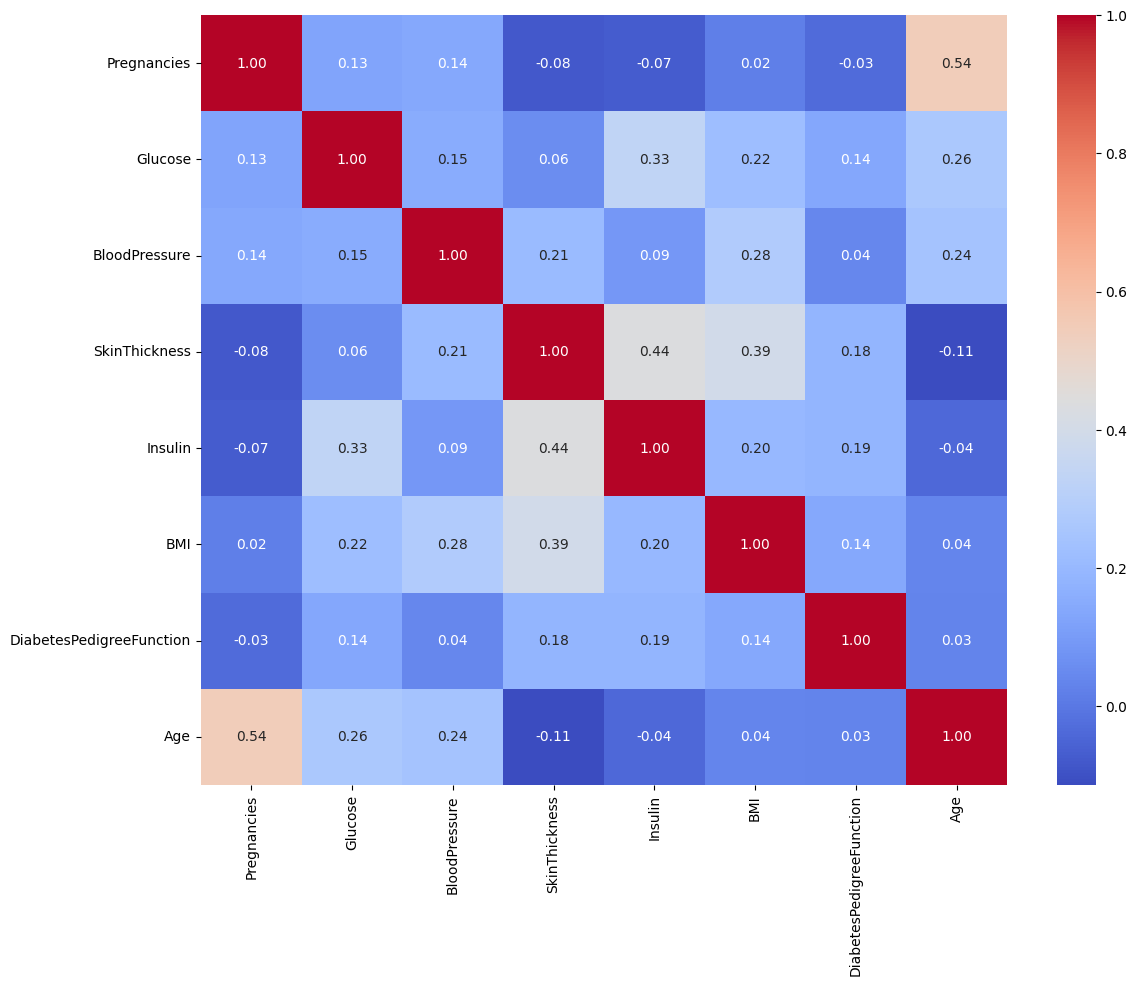

In [ ]:
# Visualizing the correlation matrix using a heatmap
plt.figure(figsize=(13,10))
sns.heatmap(df4.corr(), annot=True, fmt=".2f", cmap="coolwarm")

In [ ]:
# Split the dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(df4, df5, test_size=0.30, random_state=0)

# Feature scaling (necessary for PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Explained variance ratio: [0.26099213 0.22000951]


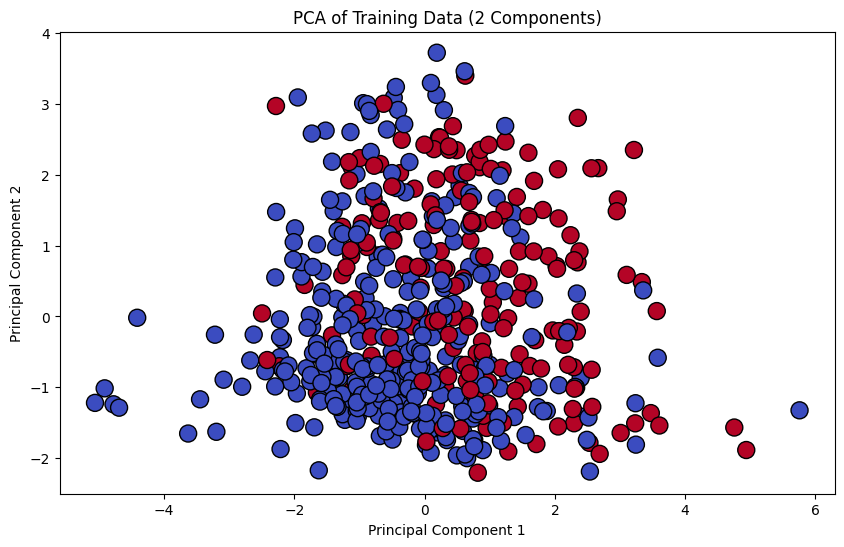

In [ ]:
# Applying PCA to reduce dimensionality (retain 2 principal components for visualization)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Visualize the explained variance ratio
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

# Visualizing the reduced dimension data in 2D space
plt.figure(figsize=(10, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=Y_train, cmap='coolwarm', edgecolor='k', s=150)
plt.title('PCA of Training Data (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [ ]:
# Training a simple classifier (e.g., Logistic Regression) after PCA for demonstration
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(random_state=0)
clf.fit(X_train_pca, Y_train)

# Making predictions on the test set
y_test_pred = clf.predict(X_test_pca)

# Evaluating the classifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
cm_test = confusion_matrix(Y_test, y_test_pred)
accuracy = accuracy_score(Y_test, y_test_pred)

print("Confusion Matrix - Test Data:\n", cm_test)
print("Accuracy on the test set: {:.3f}".format(accuracy))
print("Classification Report:\n", classification_report(Y_test, y_test_pred))

Confusion Matrix - Test Data:
 [[138  19]
 [ 42  32]]
Accuracy on the test set: 0.736
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.88      0.82       157
           1       0.63      0.43      0.51        74

    accuracy                           0.74       231
   macro avg       0.70      0.66      0.67       231
weighted avg       0.72      0.74      0.72       231

